## Импорты, seed и устройство

In [1]:
import random
import numpy as np
import torch

# Фиксация seed
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
# Массив для записи будущих экспериментов
experiments_data = []
set_seed(SEED)

In [2]:
EPOCHS = 15
models = {} # имя модели - объект модели
val_best_accs = {} # имя модели - лучший accuracy на валидации
val_histories = {} # имя модели - история accuracy на валидации

In [3]:
import pandas as pd

def save_runs_csv(experiments_data):    
    df = pd.DataFrame(experiments_data)
    
    # Сохраняем в CSV
    df.to_csv('artifacts/runs.csv', index=False)
    print("runs.csv сохранен")
    
    return df

In [4]:
import torch.optim as optim

def add_experiment(
    model_name,
    optimizer,
    epochs,
    val_acc_hist,
    val_loss_hist,
    params={"use_dropout": False, "use_batchnorm": False},
    model=None
):
    current_row = {}
    current_row['experiment_id'] = model_name
    current_row['dataset'] = 'CIFAR10'
    current_row['seed'] = SEED
    current_row['model_summary'] = f'MLP, hidden=[512,256,64], ReLU, {"no dropout" if not params['use_dropout'] else f"dropout (p={model.dropout.p})"}, {"no batchnorm" if not params['use_batchnorm'] else "batchnorm"}'
    current_row['optimizer'] = 'SGD' if type(optimizer) == optim.SGD else 'Adam'

    optimizer_params = optimizer.param_groups[0]
    current_row['lr'] =  optimizer_params['lr']
    current_row['momentum'] =  optimizer_params.get('momentum', 0)
    current_row['weight_decay'] = optimizer_params.get('weight_decay', 0)
        
    current_row['epochs_trained'] = epochs
    current_row['best_val_accuracy'] = np.round(float(max(val_acc_hist)), 4)
    current_row['best_val_loss'] = np.round(float(min(val_loss_hist)), 4)

    experiments_data.append(current_row)

In [5]:
# Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Данные и DataLoader

In [6]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split

transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  
])

# Загрузка датасета CIFAR10
trainvalset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,  
    download=True,   
    transform=transform   
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,          
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [02:59<00:00, 948kB/s]  


In [7]:
# Разбиение данных
train_size = int(0.8 * len(trainvalset))  # 80% = 40000
val_size = len(trainvalset) - train_size   # 20% = 10000

generator = torch.Generator().manual_seed(SEED)  
trainset, valset = random_split(
    trainvalset, 
    [train_size, val_size],
    generator=generator
)

print(f"Train: {len(trainset)}")
print(f"Validation: {len(valset)}")
print(f"Test: {len(testset)}")

Train: 40000
Validation: 10000
Test: 10000


In [8]:
# Создание dataloader'ов
BATCH_SIZE = 64

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True, #только для train
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

valloader = DataLoader(
    valset,
    batch_size=BATCH_SIZE,
    shuffle=False,  
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train: {len(trainloader)} батче й по {BATCH_SIZE}")
print(f"Validation: {len(valloader)} батчей по {BATCH_SIZE}")
print(f"Test: {len(testloader)} батчей по {BATCH_SIZE}")

Train: 625 батче й по 64
Validation: 157 батчей по 64
Test: 157 батчей по 64


In [9]:
def sanity_check():
    # Берем по одному батчу из каждого загрузчика
    train_batch = next(iter(trainloader))
    val_batch = next(iter(valloader))
    
    print(f"Размеры батча: {BATCH_SIZE}")

    for name, (images, labels) in zip(["TRAIN", "VAL", "TEST"], 
                                    [train_batch, val_batch, test_batch]):
        print(f"\n📊 {name}:")
        print(f"----- Shapes -----")
        print(f"  x.shape (images): {images.shape}")  # [batch_size, channels, height, width]
        print(f"  y.shape (labels): {labels.shape}")  # [batch_size]
        print(f"----- Диапазоны значений -----")
        print(f"  values: min={images.min():.2f}, max={images.max():.2f}, mean={images.mean():.2f}")
        print(f"  labels range: [{labels.min()}, {labels.max()}]")
        print(f"  NaN/Inf: {torch.isnan(images).any().item()}/{torch.isinf(images).any().item()}")

## Цикл обучения

In [10]:
from sklearn.metrics import accuracy_score
import tqdm

def accuracy_score_sklearn(outputs, labels):
    
    _, predicted = torch.max(outputs, 1)
    predicted = predicted.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    
    return accuracy_score(labels, predicted)

def train_one_epoch(model, trainloader, criterion, optimizer, device):
    model.train() 
    running_loss = 0.0
    running_acc = 0.0
    
    for images, labels in tqdm(trainloader, desc="Training", leave=False):
        # Перемещаем данные на устройство
        images, labels = images.to(device), labels.to(device)
        
        # Прямой проход
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Статистика
        running_loss += loss.item()
        running_acc += accuracy_score_sklearn(outputs, labels)
    
    # Средние значения за эпоху
    epoch_loss = running_loss / len(trainloader)
    epoch_acc = running_acc / len(trainloader)
    
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval() 
    running_loss = 0.0
    running_acc = 0.0
    
    with torch.no_grad(): 
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            running_acc += accuracy_score_sklearn(outputs, labels)
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = running_acc / len(dataloader)
    
    return epoch_loss, epoch_acc


In [11]:
import torch.nn as nn
from copy import deepcopy
from tqdm.notebook import tqdm


def train_model(model, trainloader, valloader, epochs, device, optimizer, model_name = '', early_stopping_patience=None):
    
    criterion = nn.CrossEntropyLoss()    
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    best_val_acc = 0
    
    print(f"Начало обучения {model_name}...")
    for epoch in tqdm(range(epochs), desc="Epochs"):
        print(f"\nЭпоха {epoch+1}/{epochs}")
        print("-" * 30)
        
        # Обучение
        train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer, device)
        
        # Валидация
        val_loss, val_acc = evaluate(model, valloader, criterion, device)
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Выводим результаты
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if early_stopping_patience is not None:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = deepcopy(model.state_dict()) # независимое копирование параметров
                patience_counter = 0
                print(f"Новая лучшая модель! Val Acc: {val_acc:.4f}")
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"\nРанняя остановка на эпохе {epoch+1}")
                    # Загружаем лучшую модель
                    model.load_state_dict(best_model_state)
                    break
    
    return history

In [12]:
import matplotlib.pyplot as plt

def plot_history(history, model_name='', save=False):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    ax1.plot(history['train_loss'], label='Train', marker='o')
    ax1.plot(history['val_loss'], label='Validation', marker='o')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss по эпохам')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy
    ax2.plot(history['train_acc'], label='Train', marker='o')
    ax2.plot(history['val_acc'], label='Validation', marker='o')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy по эпохам')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle(f'Обучение {model_name}') 
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # уменьшение подложки, чтобы suptitle не налезал
    if save:
        p = f'artifacts/figures/curves_best.png'
        plt.savefig(p)
        print(f"График сохранен: {p}")
    plt.show()


In [13]:
def run_model(
    model,
    epochs,
    optimizer,
    params={"use_dropout": False, "use_batchnorm": False},
    early_stopping_patience=None,
    model_name="",
    save=False,
    return_full_history=False
):
    history = train_model(
        model,
        trainloader,
        valloader,
        epochs,
        device,
        optimizer=optimizer,
        early_stopping_patience=early_stopping_patience,
        model_name=model_name,
    )
    plot_history(history, model_name=model_name, save=save)
    add_experiment(
        model_name,
        optimizer,
        epochs,
        history["val_acc"],
        history["val_loss"],
        params=params,
        model=model,
    )
    if not return_full_history:
        return max(history["val_acc"])
    return history["val_acc"]


## Часть A (S08): регуляризация и переобучение

In [14]:
# Базовая модель (MLP) 
class E1(nn.Module):
    def __init__(self, input_size=3*32*32, hidden_sizes=[512, 256, 64], num_classes=10):
        super(E1, self).__init__()
        
        # Flatten слой для преобразования изображения в вектор
        self.flatten = nn.Flatten()
        
        # Слои MLP
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.fc4 = nn.Linear(hidden_sizes[2], num_classes)  # logits
        
        # Активации
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # x shape: [batch_size, 3, 32, 32]
        x = self.flatten(x) # [batch_size, 3*32*32]
        x = self.relu(self.fc1(x)) # -[batch_size, 1024]
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x) # [batch_size, 10] 
        return x

In [15]:
# E1 c dropout 
class E2(nn.Module):
    def __init__(self, input_size=3*32*32, hidden_sizes=[512, 256, 64], 
                 num_classes=10, dropout_p=0.3):
        super(E2, self).__init__()
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.fc4 = nn.Linear(hidden_sizes[2], num_classes)
        
        # Dropout слои
        self.dropout = nn.Dropout(dropout_p)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.flatten(x)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        
        x = self.fc4(x)
        return x

In [16]:
# E1 c batchnorm 
class E3(nn.Module):
    def __init__(self, input_size=3*32*32, hidden_sizes=[512, 256, 64], num_classes=10):
        super(E3, self).__init__()
        
        self.flatten = nn.Flatten()
        
        # Слои MLP с BatchNorm
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0])
        
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1])
        
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2])
        
        self.fc4 = nn.Linear(hidden_sizes[2], num_classes)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.flatten(x)
        
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        
        x = self.fc4(x)
        return x

### Обучение моделей S08 

Начало обучения E1...


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]


Эпоха 1/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.6885, Train Acc: 0.3968
Val Loss: 1.5385, Val Acc: 0.4552

Эпоха 2/15
------------------------------


...

Train Loss: 0.5904, Train Acc: 0.7883
Val Loss: 1.7718, Val Acc: 0.5306

Эпоха 14/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.5419, Train Acc: 0.8082
Val Loss: 1.9563, Val Acc: 0.5275

Эпоха 15/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.5046, Train Acc: 0.8187
Val Loss: 2.0689, Val Acc: 0.5235


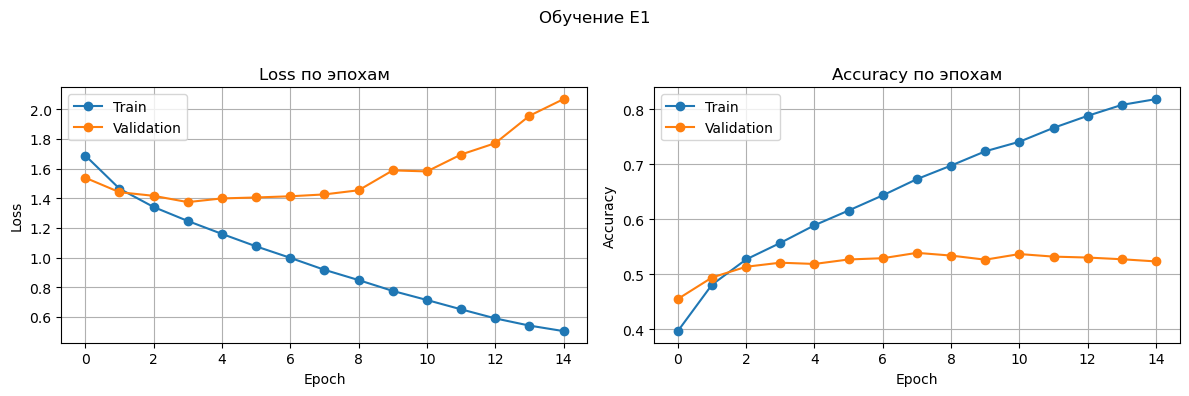

Best accuracy: 0.5391122611464968


In [17]:
models['E1'] = E1().to(device)
val_best_accs["E1"] = run_model(
    models["E1"],
    EPOCHS,
    optimizer=optim.Adam(models["E1"].parameters()),
    model_name="E1",
)
print(f"Best accuracy: {val_best_accs['E1']}")

Начало обучения E2...


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]


Эпоха 1/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.8426, Train Acc: 0.3404
Val Loss: 1.6273, Val Acc: 0.4210

Эпоха 2/15
------------------------------


...

Train Loss: 1.2949, Train Acc: 0.5434
Val Loss: 1.3761, Val Acc: 0.5266

Эпоха 14/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.2763, Train Acc: 0.5484
Val Loss: 1.3538, Val Acc: 0.5306

Эпоха 15/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.2612, Train Acc: 0.5535
Val Loss: 1.3674, Val Acc: 0.5278


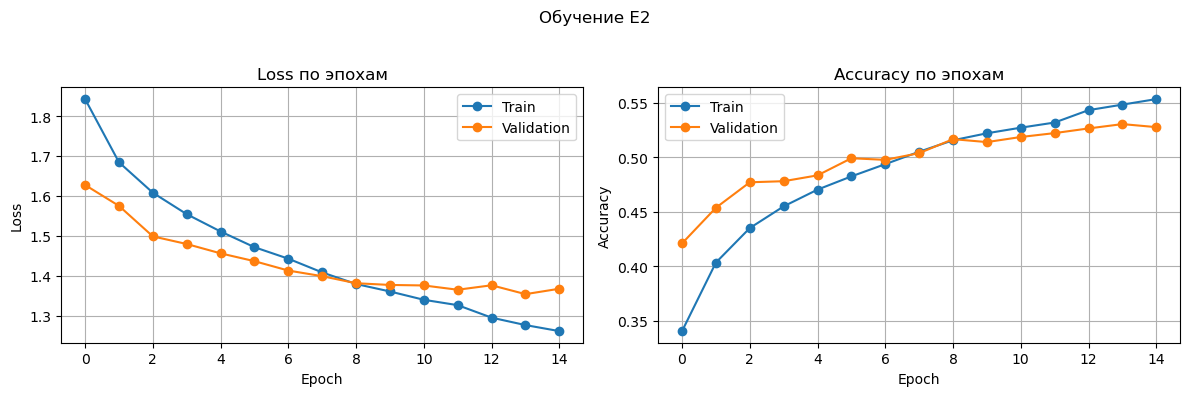

Best accuracy: 0.5305533439490446


In [18]:
models['E2'] = E2(dropout_p=0.3).to(device)
val_best_accs['E2'] = run_model(
    models["E2"],
    EPOCHS,
    optimizer=optim.Adam(models["E2"].parameters()),
    params={"use_dropout": True, "use_batchnorm": False},
    model_name="E2",
)
print(f"Best accuracy: {val_best_accs['E2']}")

Начало обучения E3...


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]


Эпоха 1/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.6578, Train Acc: 0.4056
Val Loss: 1.4903, Val Acc: 0.4651

Эпоха 2/15
------------------------------


...

Train Loss: 0.6504, Train Acc: 0.7686
Val Loss: 1.4748, Val Acc: 0.5504

Эпоха 14/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.6023, Train Acc: 0.7852
Val Loss: 1.5164, Val Acc: 0.5461

Эпоха 15/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.5522, Train Acc: 0.8017
Val Loss: 1.5859, Val Acc: 0.5438


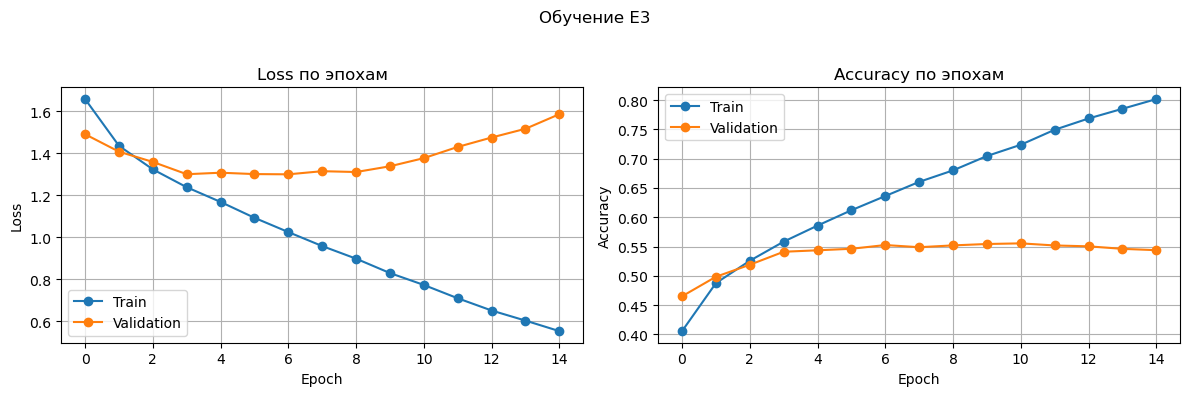

Best accuracy: 0.5554339171974523


In [19]:
models['E3'] = E3().to(device)
val_best_accs['E3'] = run_model(
    models["E3"],
    EPOCHS,
    optimizer=optim.Adam(models["E3"].parameters()),
    params={"use_dropout": False, "use_batchnorm": True},
    model_name="E3",
)
print(f"Best accuracy: {val_best_accs['E3']}")


Модель E3 показала лучший результат
Начало обучения E4...


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]


Эпоха 1/30
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.6558, Train Acc: 0.4079
Val Loss: 1.4825, Val Acc: 0.4739
Новая лучшая модель! Val Acc: 0.4739

Эпоха 2/30
------------------------------


...

Train Loss: 0.7711, Train Acc: 0.7263
Val Loss: 1.3962, Val Acc: 0.5461

Эпоха 12/30
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.7128, Train Acc: 0.7491
Val Loss: 1.4363, Val Acc: 0.5512

Эпоха 13/30
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.6558, Train Acc: 0.7663
Val Loss: 1.5167, Val Acc: 0.5418

Ранняя остановка на эпохе 13
График сохранен: artifacts/figures/curves_best.png


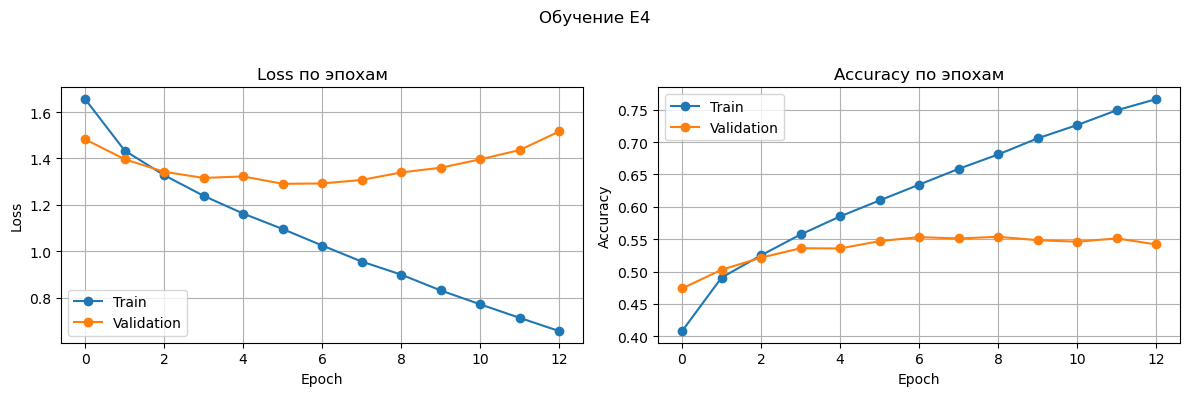

In [20]:
early_stopping_patience = 4

# Определение лучшей модели
best_model_name = max_key = max(val_best_accs, key=val_best_accs.get)
print(f"\nМодель {best_model_name} показала лучший результат")
best_model = models[best_model_name]
BestModelClass = type(best_model)

# Обучение лучшей модели
models['E4'] = BestModelClass().to(device)
val_best_accs['E4'] = run_model(
    models["E4"],
    EPOCHS*2,
    optimizer=optim.Adam(models["E4"].parameters()),
    early_stopping_patience=early_stopping_patience, 
    params={"use_dropout": isinstance(models['E4'], E2), "use_batchnorm": isinstance(models['E4'], E3)},
    model_name=f"E4",
    save=True
)

In [21]:
# Оценка
_, test_accuracy = evaluate(models['E4'], testloader, nn.CrossEntropyLoss(), device)
print(f"Test accuracy: {round(test_accuracy, 4)}")

Test accuracy: 0.5433


In [22]:
# Сохранение лучшей модели
p = 'artifacts/best_model.pt'
torch.save(models['E4'].state_dict(), p)
print(f"Модель сохранена: {p}")

Модель сохранена: artifacts/best_model.pt


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def draw_confusion_matrix(model, testloader, device, title='Confusion Matrix', p='confusion_matrix'):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    # Визуализация
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Предсказанные метки')
    plt.ylabel('Истинные метки')
    plt.title(title)
    
    plt.savefig(f'artifacts/figures/{p}.png', dpi=150)
    plt.show()
    
    class_acc = cm.diagonal() / cm.sum(axis=1)
    print("\nAccuracy по классам:")
    for i, acc in enumerate(class_acc):
        print(f"Класс {i}: {acc:.4f}")
    
    return cm

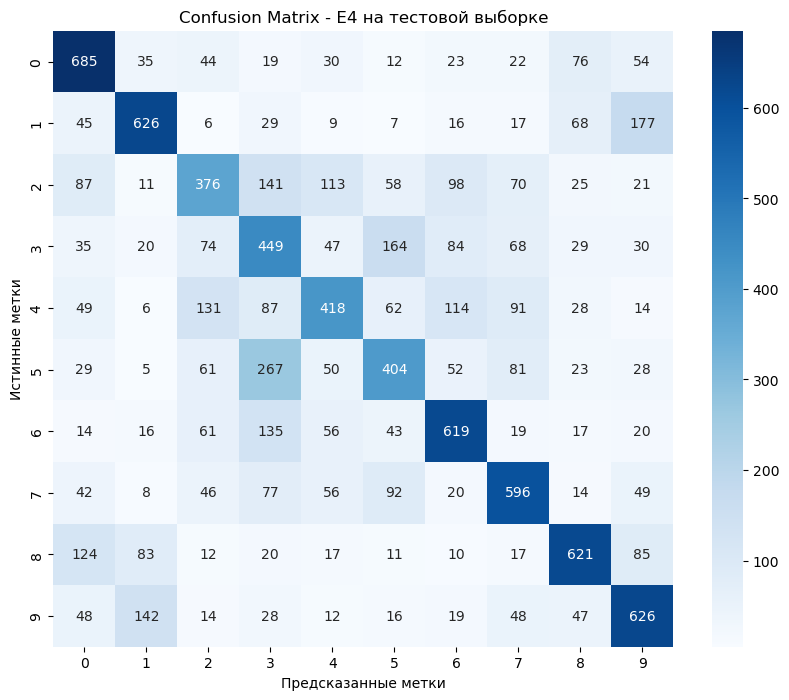


Accuracy по классам:
Класс 0: 0.6850
Класс 1: 0.6260
Класс 2: 0.3760
Класс 3: 0.4490
Класс 4: 0.4180
Класс 5: 0.4040
Класс 6: 0.6190
Класс 7: 0.5960
Класс 8: 0.6210
Класс 9: 0.6260


In [24]:
cm = draw_confusion_matrix(best_model, testloader, device, title=f'Confusion Matrix - E4 на тестовой выборке', p='confusion_matrix_best_model_on_test')

In [25]:
import json

use_batchnorm = False
use_dropout = False

def save_config(model, filename="artifacts/best_config.json"):
    params = {
        'use_dropout': False,
        'use_batchnorm': False
    }
    
    if isinstance(model, E2):
        arch = "E2"
        dropout = model.dropout.p
        params['use_dropout'] = True
    elif isinstance(model, E3):
        arch = "E3"
        dropout = None
        params['use_batchnorm'] = True
    else:
        arch = "E1"
        dropout = None
    
    config = {
        "seed": SEED,
        "dataset": "CIFAR-10",
        "architecture": {
            "parent": arch,
            "hidden_layers": [512, 256, 64],
            "activation": "ReLU",
            "batchnorm": params['use_batchnorm'],
            "dropout": dropout
        },
        "training": {
            "optimizer": "Adam",
            "batch_size": BATCH_SIZE,
            "learning_rate": 0.001,
            "early_stopping_patience": early_stopping_patience,
            "momentum": 0.0,
            "weight_decay": 0.0
        },
        "results": {
            "best_val_accuracy": round(val_best_accs['E4'], 4),
            "test_accuracy": round(test_accuracy, 4)
        }
    }
    
    with open(filename, 'w') as f:
        json.dump(config, f, indent=4)
    
    print(f"Конфиг сохранен: {filename}")
    return params

In [26]:
arch_params = save_config(best_model)

Конфиг сохранен: artifacts/best_config.json


## Часть B (S09): LR, оптимизаторы, weight decay 

In [27]:
class E4(nn.Module):
    def __init__(self, input_size=3*32*32, hidden_sizes=[512, 256, 64], 
                 num_classes=10, use_batchnorm=False, use_dropout=False, dropout_p=0.3):
        super(E4, self).__init__()
        
        self.flatten = nn.Flatten()
        self.use_batchnorm = use_batchnorm
        self.use_dropout = use_dropout
        
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.fc4 = nn.Linear(hidden_sizes[2], num_classes)
        
        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(hidden_sizes[0])
            self.bn2 = nn.BatchNorm1d(hidden_sizes[1])
            self.bn3 = nn.BatchNorm1d(hidden_sizes[2])
        
        self.dropout = nn.Dropout(dropout_p) if use_dropout else None
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.flatten(x)
        
        # Слой 1
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu(x)
        if self.use_dropout:
            x = self.dropout(x)
        
        # Слой 2
        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu(x)
        if self.use_dropout:
            x = self.dropout(x)
        
        # Слой 3
        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu(x)
        if self.use_dropout:
            x = self.dropout(x)
        
        # Выходной слой
        x = self.fc4(x)
        return x

In [28]:
def comparison_lr_plot(o1_acc, o2_acc):
    plt.figure(figsize=(10, 6))
    
    plt.plot(range(1, len(o1_acc)+1), o1_acc, 'r-o', linewidth=2, markersize=6, label='O1: LR=0.1')
    plt.plot(range(1, len(o2_acc)+1), o2_acc, 'b-o', linewidth=2, markersize=6, label='O2: LR=1e-5')
    
    plt.xlabel('Эпоха')
    plt.ylabel('Validation Accuracy')
    plt.title('Сравнение Learning Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.text(len(o1_acc), o1_acc[-1], f'{o1_acc[-1]:.3f}', fontsize=9, color='red')
    plt.text(len(o2_acc), o2_acc[-1], f'{o2_acc[-1]:.3f}', fontsize=9, color='blue')
    
    p = 'artifacts/figures/curves_lr_extremes.png'
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"График сохранен: {p}")

In [29]:
for i in range(1, 4):
    models[f'O{i}'] = E4(use_batchnorm=arch_params['use_batchnorm'], use_dropout=arch_params['use_dropout']).to(device)

Начало обучения O1...


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]


Эпоха 1/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.8571, Train Acc: 0.3232
Val Loss: 1.7601, Val Acc: 0.3605

Эпоха 2/15
------------------------------


...

Train Loss: 1.2142, Train Acc: 0.5677
Val Loss: 1.4107, Val Acc: 0.5161

Эпоха 14/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.1822, Train Acc: 0.5819
Val Loss: 1.4479, Val Acc: 0.4980

Эпоха 15/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.1582, Train Acc: 0.5909
Val Loss: 1.4218, Val Acc: 0.5294


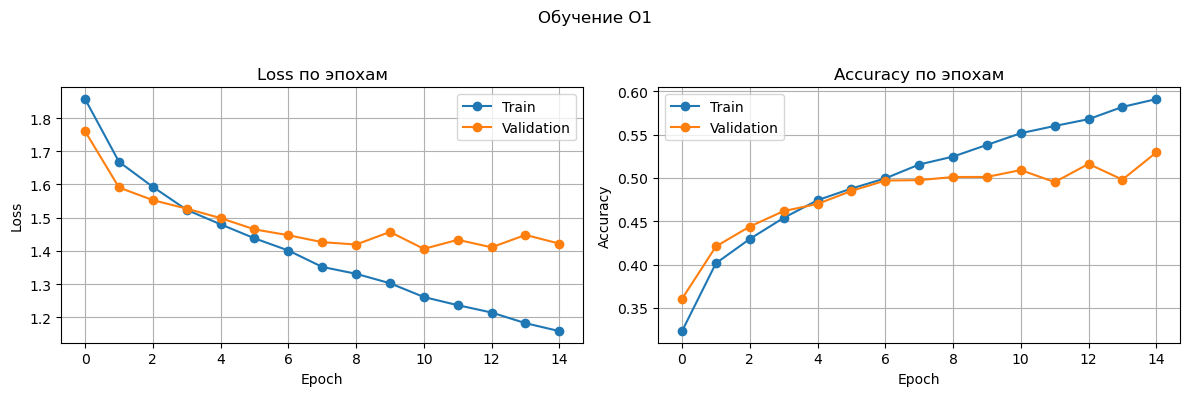

Best accuracy: 0.529359076433121


In [30]:
optimizer_o1 = optim.Adam(models['O1'].parameters(), lr=0.1)  # Слишком большой LR
val_histories['O1'] = run_model(
    models["O1"],
    EPOCHS,
    optimizer=optimizer_o1,
    params=arch_params,
    model_name="O1",
    return_full_history=True
)
val_best_accs['O1'] = max(val_histories['O1'])
print(f"Best accuracy: {val_best_accs['O1']}")

Начало обучения O2...


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]


Эпоха 1/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.9792, Train Acc: 0.3176
Val Loss: 1.8382, Val Acc: 0.3950

Эпоха 2/15
------------------------------


...

Train Loss: 1.2393, Train Acc: 0.6125
Val Loss: 1.4048, Val Acc: 0.5286

Эпоха 14/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.2065, Train Acc: 0.6233
Val Loss: 1.3932, Val Acc: 0.5261

Эпоха 15/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.1737, Train Acc: 0.6343
Val Loss: 1.3830, Val Acc: 0.5302


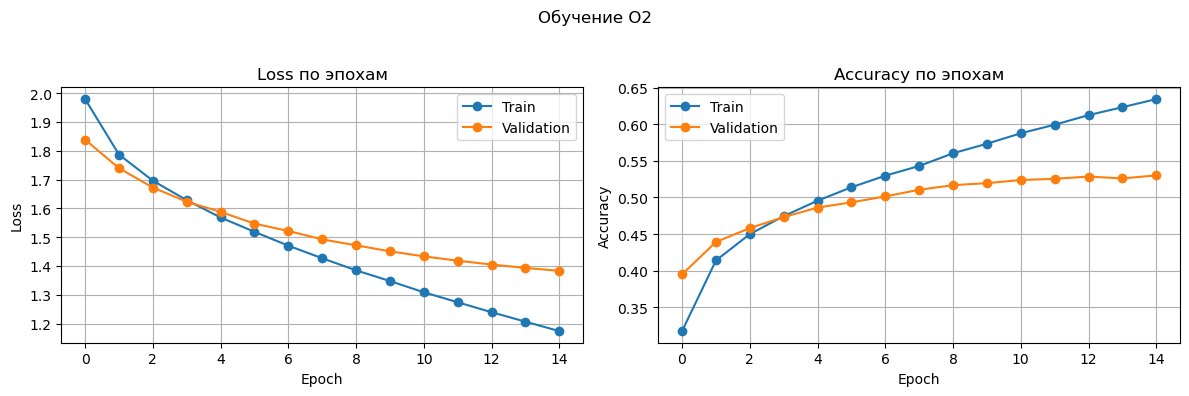

Best accuracy: 0.53015525477707


In [31]:
optimizer_o2 = optim.Adam(models['O2'].parameters(), lr=1e-5)
val_histories['O2'] = run_model(
    models["O2"],
    EPOCHS,
    optimizer=optimizer_o2,
    params=arch_params,
    model_name="O2", 
    return_full_history=True
)
val_best_accs['O2'] = max(val_histories['O2'])
print(f"Best accuracy: {val_best_accs['O2']}")

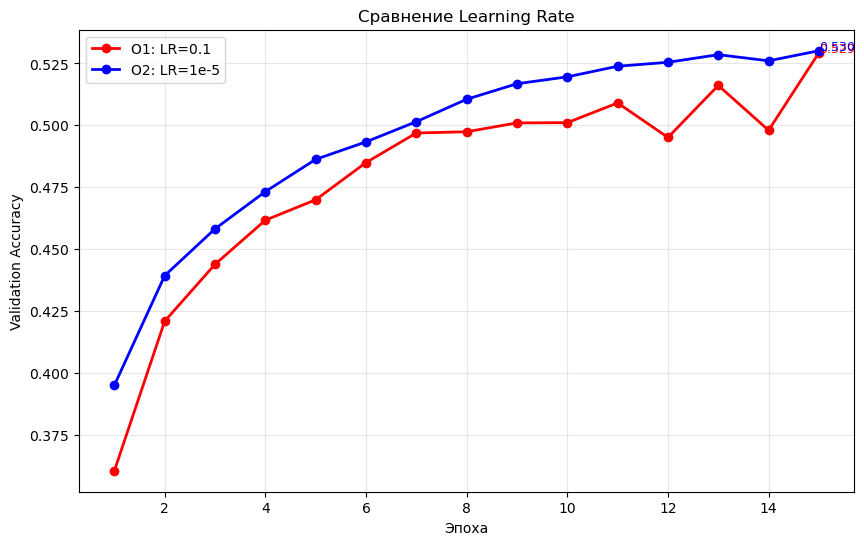

График сохранен: artifacts/figures/curves_lr_extremes.png


In [32]:
comparison_lr_plot(val_histories['O1'], val_histories['O2'])

Начало обучения O3...


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]


Эпоха 1/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 1.6398, Train Acc: 0.4132
Val Loss: 1.5045, Val Acc: 0.4664

Эпоха 2/15
------------------------------


...

Train Loss: 0.7347, Train Acc: 0.7404
Val Loss: 1.4859, Val Acc: 0.5418

Эпоха 14/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.6907, Train Acc: 0.7550
Val Loss: 1.4959, Val Acc: 0.5382

Эпоха 15/15
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Train Loss: 0.6528, Train Acc: 0.7678
Val Loss: 1.5128, Val Acc: 0.5458


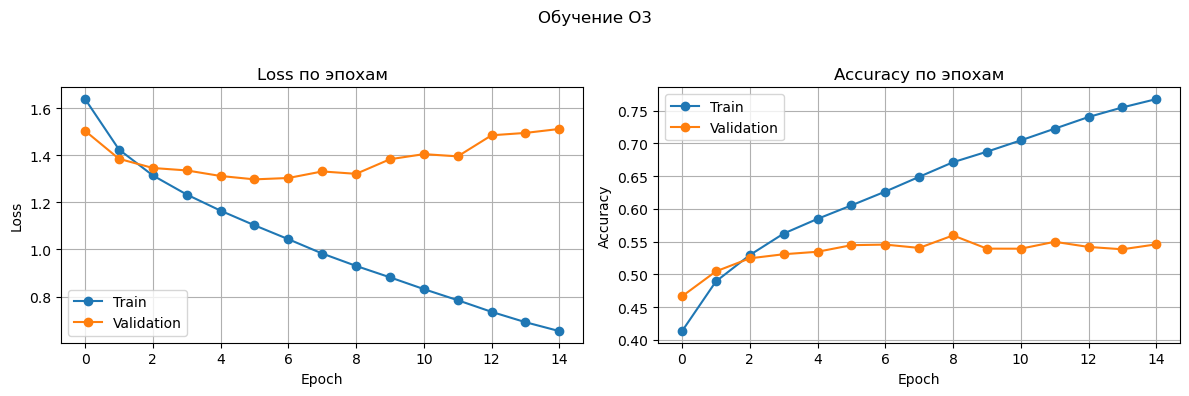

Best accuracy: 0.5594148089171974


In [33]:
optimizer_o3 = optim.SGD(models['O3'].parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
val_best_accs['O3'] = run_model(
    models["O3"],
    EPOCHS,
    optimizer=optimizer_o3,
    params=arch_params,
    model_name="O3"
)
print(f"Best accuracy: {val_best_accs['O3']}")

## Таблица результатов

In [34]:
results = save_runs_csv(experiments_data)

runs.csv сохранен
